# Notebook 03: Modelling and Business Recommendations

**Project:** Credit card customer churn (BankChurners)
**Input:** `data/processed/churn_features.csv` from Notebook 02 (10,127 rows, 36 columns)
**Output:** a scored customer file for reporting and a short set of quantified recommendations

## Scope

This notebook trains and compares churn models, picks one, explains what drives it,
turns the chosen model into a customer-level risk score, and states the business
recommendations the analysis supports. It follows the handoff instructions written
at the end of Notebook 02 to the letter.

Four rules carry over from the earlier notebooks:

1. **Every number in the commentary is printed by the cell above it.** No figure is
   carried from memory.
2. **The test set is not touched until the final comparison.** Every model is
   cross-validated on the training rows only, so the reported scores are honest.
3. **Accuracy is not used as a headline.** The classes are imbalanced (16 percent
   churn), so the metrics are recall, precision, and PR-AUC, with the business
   trade-off stated in plain language.
4. **No claim runs ahead of the data.** This is a snapshot with no timestamps, so
   the model identifies the behavioural signature of an at-risk account. It is not
   presented as a forecast made weeks in advance.

A note on reproducibility: every result below is produced with `random_state = 42`
and scikit-learn 1.8. Exact figures in the commentary match the printed cell output
from that setup. A different library version may shift the last decimal place.


## 1. Imports and load

Load the model-ready file from Notebook 02, separate the target, and remove the
identifier from the feature matrix immediately. `CLIENTNUM` is a nine-digit account
number, not a predictor, and a tree will happily overfit to it if it is left in.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, roc_auc_score, recall_score,
                             precision_score, f1_score, confusion_matrix,
                             precision_recall_curve)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Resolve the repo root whether the kernel starts in notebooks/ or at the root.
BASE = Path.cwd()
while not (BASE / "data").is_dir() and BASE != BASE.parent:
    BASE = BASE.parent

FEATURES_PATH = BASE / "data" / "processed" / "churn_features.csv"   # Notebook 02 output
CHARTS_DIR = BASE / "outputs" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEATURES_PATH)
print("Loaded:", df.shape)

y = df["Churn"]
X = df.drop(columns=["CLIENTNUM", "Churn"])
print("Feature matrix:", X.shape)
print("Target positive rate:", round(y.mean() * 100, 2), "percent churn")


Loaded: (10127, 36)
Feature matrix: (10127, 34)
Target positive rate: 16.07 percent churn


## 2. The scoring frame: why accuracy is the wrong headline

Before any model is trained, it is worth being explicit about the number a model has
to beat. With only 16 percent of customers churning, a model that predicts "no churn"
for everyone is already right most of the time and catches nobody. The cell below
prints that floor so the rest of the notebook is measured against the right bar.


In [2]:
majority_accuracy = round((y == 0).mean() * 100, 2)
print("Baseline: predict that nobody churns")
print("  Accuracy :", majority_accuracy, "percent  (this is the bar accuracy has to beat)")
print("  Recall   : 0.0  (it catches zero churners)")
print("  PR-AUC   :", round(y.mean(), 3), " (a random ranker scores the base rate)")
print()
print("Metrics used from here on:")
print("  Recall    = share of real churners the model catches")
print("  Precision = share of flagged customers who are real churners")
print("  PR-AUC    = precision/recall trade-off across all thresholds (the headline)")


Baseline: predict that nobody churns
  Accuracy : 83.93 percent  (this is the bar accuracy has to beat)
  Recall   : 0.0  (it catches zero churners)
  PR-AUC   : 0.161  (a random ranker scores the base rate)

Metrics used from here on:
  Recall    = share of real churners the model catches
  Precision = share of flagged customers who are real churners
  PR-AUC    = precision/recall trade-off across all thresholds (the headline)


**Inference.** A model that predicts "no churn" for every customer is right
83.93 percent of the time on this data, purely because churners are rare. That is
the accuracy any real model has to clear just to exist, and it saves nobody. This is
why accuracy is not the headline here. The three metrics that matter are recall (how
many real churners we catch), precision (how clean the flagged list is), and PR-AUC,
which summarises the precision and recall trade-off across every threshold and is the
single number the models are ranked on.


## 3. Train and test split

Split first, before any fitting, model choice, or threshold tuning. The split is
stratified on `Churn` so both sides hold the same 16 percent churn rate. The test set
is set aside and not used until section 5.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| churners:", int(y_train.sum()),
      "| churn rate:", round(y_train.mean() * 100, 2), "percent")
print("Test :", X_test.shape, "| churners:", int(y_test.sum()),
      "| churn rate:", round(y_test.mean() * 100, 2), "percent")


Train: (8101, 34) | churners: 1302 | churn rate: 16.07 percent
Test : (2026, 34) | churners: 325 | churn rate: 16.04 percent


**Inference.** The split preserves the churn rate almost exactly: 16.07 percent
in training and 16.04 percent in test. The 2,026 test rows, 325 of them churners, are
now sealed off. Every model below is cross-validated on the 8,101 training rows only,
which is what keeps the final numbers trustworthy: nothing sees the test set while it
is being fitted or chosen.


## 4. Three candidate models, cross-validated on the training set

Three models, chosen to span the useful range from simple to strong:

- **Logistic regression**, the interpretable baseline. It is wrapped in a pipeline
  that applies `np.log` to `Total_Trans_Amt` and then standardises every column, so
  the linear model gets the benefit of the log transform Notebook 02 measured
  (`Total_Trans_Amt` correlation improved from -0.169 to -0.227 under a log). The log
  lives inside the pipeline, not in the shared file, exactly as Notebook 02 specified,
  so it helps the linear model without affecting the trees.
- **Random forest**, a bagged tree ensemble.
- **Histogram gradient boosting**, a boosted tree ensemble. This is scikit-learn's
  own gradient boosting implementation, chosen so the whole project runs on a single
  dependency with no XGBoost install. It benchmarks close to XGBoost on tabular data.

All three use balanced class weights so the rare churn class is not ignored. Each is
scored with five-fold cross-validation on the training set, using average precision
(PR-AUC) as the fold metric.


In [4]:
# Logistic pipeline: log(Total_Trans_Amt) inside the pipeline, then scale, then fit.
log_cols = ["Total_Trans_Amt"]
other_cols = [c for c in X.columns if c not in log_cols]

preprocess = ColumnTransformer([
    ("log", FunctionTransformer(np.log, feature_names_out="one-to-one"), log_cols),
    ("pass", "passthrough", other_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])

rf = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE
)

hgb = HistGradientBoostingClassifier(
    learning_rate=0.1, max_iter=300, class_weight="balanced",
    random_state=RANDOM_STATE
)

models = {
    "LogisticRegression": logreg,
    "RandomForest": rf,
    "HistGradientBoosting": hgb,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Five-fold cross-validation on the training set, scoring = PR-AUC")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision")
    cv_results[name] = scores
    print(f"  {name:22s} PR-AUC {scores.mean():.3f} +/- {scores.std():.3f}")


Five-fold cross-validation on the training set, scoring = PR-AUC
  LogisticRegression     PR-AUC 0.797 +/- 0.011
  RandomForest           PR-AUC 0.930 +/- 0.017
  HistGradientBoosting   PR-AUC 0.971 +/- 0.007


  RandomForest           PR-AUC 0.930 +/- 0.017


  HistGradientBoosting   PR-AUC 0.971 +/- 0.007


**Inference.** The ranking is clear and stable. Gradient boosting leads at 0.971
PR-AUC, the random forest follows at 0.930, and the logistic baseline trails at 0.797.
Every standard deviation is under 0.02, which says the order is a property of the data,
not of one lucky fold.

The logistic model is doing exactly what a linear baseline should do: mark the ceiling a straight line can reach. The roughly 0.17 gap up to gradient boosting is what the non-linear models add by capturing threshold and interaction effects a line cannot represent.



## 5. Held-out test performance and model selection

Now the models are fitted on the full training set and scored once on the untouched
test set. At the default 0.5 threshold, recall and precision are reported alongside
the threshold-free PR-AUC and ROC-AUC.


In [5]:
rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "PR_AUC": round(average_precision_score(y_test, proba), 3),
        "ROC_AUC": round(roc_auc_score(y_test, proba), 3),
        "recall@0.5": round(recall_score(y_test, pred), 3),
        "precision@0.5": round(precision_score(y_test, pred), 3),
        "f1@0.5": round(f1_score(y_test, pred), 3),
    })

results = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_name = results.iloc[0]["model"]
best_model = fitted[best_name]
print()
print("Selected model:", best_name)


               model  PR_AUC  ROC_AUC  recall@0.5  precision@0.5  f1@0.5
HistGradientBoosting   0.967    0.992       0.895          0.939   0.917
        RandomForest   0.934    0.984       0.806          0.891   0.847
  LogisticRegression   0.784    0.938       0.837          0.559   0.670

Selected model: HistGradientBoosting


**Inference.** The test set confirms the cross-validation order. Gradient boosting
wins on PR-AUC at 0.967 and, at the default cut, catches 89.5 percent of churners while
keeping 93.9 percent of its alarms correct. The random forest is a clear step behind on
both. The logistic model is the instructive contrast: its ROC-AUC of 0.938 looks fine,
but its precision at 0.5 is only 55.9 percent, meaning nearly half the customers it
flags are false alarms. That split between a healthy ROC-AUC and a weak precision is the
whole reason this project reports PR-AUC and precision rather than ROC-AUC alone on an
imbalanced target.

**A necessary caution on the size of these numbers.** A PR-AUC near 0.97 is unusually
high for churn work, and it should be read with two caveats, not celebrated at face
value. First, this is a clean, compact teaching dataset that separates far more easily
than a real bank's production data would, so these figures are not a promise of
production performance. Second, and more important, Notebook 02 established that this is
a snapshot with no timestamps. Some of the behavioural signal, a collapsed transaction
count or a zeroed balance, may be recorded at the same time as or after the decision to
leave. The honest description of this model is that it identifies the behavioural
signature of an at-risk account, not that it forecasts churn weeks ahead. Reading 0.97
as forward-looking forecast accuracy would overstate what this data can support.


## 6. What drives the model, and resolving the overlapping features

Two questions here. First, which features actually carry the model. Permutation
importance is used rather than the built-in tree importance, because permutation
importance is measured on the test set and is more honest when features are correlated:
it asks how much test PR-AUC falls when a column is shuffled.

Second, Notebook 02 left one decision open: `zero_revolving_balance`,
`Total_Revolving_Bal`, and `Avg_Utilization_Ratio` all describe the same underlying
quantity, and it asked this notebook to resolve the overlap with importance plus a
correlation check rather than by guessing. That is done below.


In [6]:
# Permutation importance on the test set (robust to correlated features).
perm = permutation_importance(
    best_model, X_test, y_test, scoring="average_precision",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
importance = (pd.DataFrame({
        "feature": X_test.columns,
        "drop_in_PR_AUC": perm.importances_mean,
        "std": perm.importances_std,
    })
    .sort_values("drop_in_PR_AUC", ascending=False)
    .reset_index(drop=True))

print("Top 10 features by permutation importance (mean drop in test PR-AUC):")
print(importance.head(10).round(4).to_string(index=False))
print()

print("Engineered flags and the missing-data flag, for reference:")
watch = ["zero_revolving_balance", "sharp_activity_decline", "has_unknown_demographic"]
print(importance[importance.feature.isin(watch)].round(4).to_string(index=False))


Top 10 features by permutation importance (mean drop in test PR-AUC):
                 feature  drop_in_PR_AUC    std
          Total_Trans_Ct          0.4315 0.0184
         Total_Trans_Amt          0.2967 0.0128
Total_Relationship_Count          0.0364 0.0059
    Total_Amt_Chng_Q4_Q1          0.0327 0.0037
     Total_Revolving_Bal          0.0200 0.0038
            Customer_Age          0.0164 0.0017
     Total_Ct_Chng_Q4_Q1          0.0149 0.0031
  Months_Inactive_12_mon          0.0111 0.0027
   Contacts_Count_12_mon          0.0081 0.0023
            Credit_Limit          0.0076 0.0022

Engineered flags and the missing-data flag, for reference:
                feature  drop_in_PR_AUC    std
has_unknown_demographic          0.0002 0.0002
 zero_revolving_balance          0.0001 0.0001
 sharp_activity_decline          0.0000 0.0000


In [7]:
# Resolve the overlapping cluster: correlation plus importance.
cluster = ["zero_revolving_balance", "Total_Revolving_Bal", "Avg_Utilization_Ratio"]
print("Correlation among the overlapping columns (training set):")
print(X_train[cluster].corr().round(3).to_string())
print()
print("Their permutation importances:")
print(importance[importance.feature.isin(cluster)].round(4).to_string(index=False))


Correlation among the overlapping columns (training set):
                        zero_revolving_balance  Total_Revolving_Bal  Avg_Utilization_Ratio
zero_revolving_balance                   1.000               -0.812                 -0.567
Total_Revolving_Bal                     -0.812                1.000                  0.625
Avg_Utilization_Ratio                   -0.567                0.625                  1.000

Their permutation importances:
               feature  drop_in_PR_AUC    std
   Total_Revolving_Bal          0.0200 0.0038
 Avg_Utilization_Ratio          0.0016 0.0009
zero_revolving_balance          0.0001 0.0001


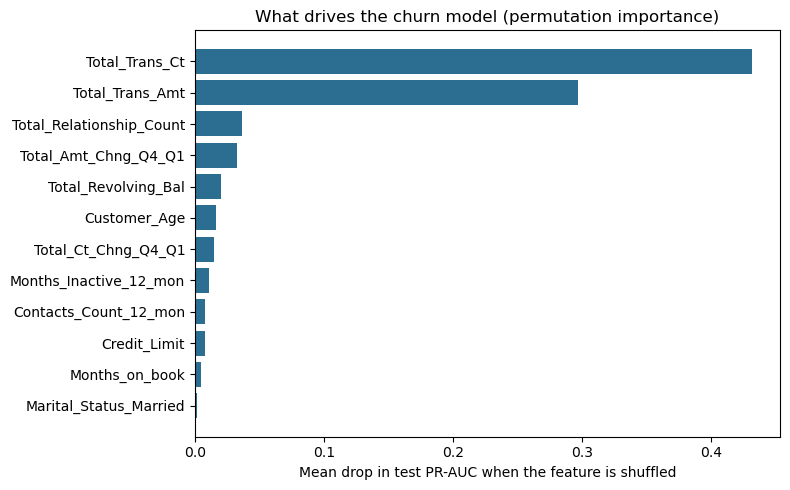

In [8]:
# Chart: top-12 permutation importance, saved for the README and dashboard.
top = importance.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["drop_in_PR_AUC"], color="#2c6e91")
ax.set_xlabel("Mean drop in test PR-AUC when the feature is shuffled")
ax.set_title("What drives the churn model (permutation importance)")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "nb03_permutation_importance.png", dpi=120)
plt.show()


**Inference.** Two features carry almost the entire model. Shuffling
`Total_Trans_Ct` costs 0.43 of PR-AUC and shuffling `Total_Trans_Amt` costs 0.30.
Everything else is an order of magnitude smaller. Transaction frequency and spend are
the churn story on this data; the next tier (`Total_Relationship_Count`, the Q4-to-Q1
amount change, revolving balance) only fills in the edges.

**"The engineered flags rank at the very bottom. Notebook 02 predicted this would happen."** `zero_revolving_balance`, `sharp_activity_decline` and
`has_unknown_demographic` all sit at essentially zero. Notebook 02 said this would
happen: a tree can split on the parent columns directly, so the flags add nothing for a
tree. Their value was never meant to be here. It is that they let a linear baseline
express a cliff and a threshold, and that they turn a finding into a rule a retention
team can run. The near-zero `has_unknown_demographic` also confirms, a second time, the
negative result from Notebook 02: incomplete records do not predict churn.

**Cluster resolution.** The three overlapping columns are correlated as expected, with
the flag and the balance at -0.81. Ranked by importance, `Total_Revolving_Bal` (0.020)
holds the signal, while the ratio (0.0016) and the flag (0.0001) are redundant to the
tree once the raw balance is present. Decision: treat `Total_Revolving_Bal` as the
modelling column of the three, and keep the flag and the ratio only as business-facing
descriptors, not as separate model drivers. Nothing is dropped from the file, because
none of them harms the tree, but any reporting should credit one balance signal, not
three.


## 7. The operating threshold: turning scores into a call list

A probability is not yet a decision. The retention team needs a cut point above which
a customer goes on the outreach list. The table below shows what each threshold buys on
the test set, and the precision-recall curve marks the default operating point.


In [9]:
proba_test = best_model.predict_proba(X_test)[:, 1]

rows = []
for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "threshold": t,
        "customers_flagged": int(pred.sum()),
        "real_churners_caught": int(tp),
        "recall": round(tp / (tp + fn), 3),
        "precision": round(tp / (tp + fp), 3),
        "false_alarms": int(fp),
    })
threshold_table = pd.DataFrame(rows)
print("Test set: 2,026 customers, 325 of them churners")
print(threshold_table.to_string(index=False))
print()

pred_05 = (proba_test >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_05).ravel()
print("Confusion matrix at threshold 0.5:")
print(f"  Real churners caught : {tp} of {tp + fn}")
print(f"  Real churners missed : {fn}")
print(f"  False alarms         : {fp} of {tn + fp} retained customers")


Test set: 2,026 customers, 325 of them churners
 threshold  customers_flagged  real_churners_caught  recall  precision  false_alarms
       0.2                340                   299   0.920      0.879            41
       0.3                329                   295   0.908      0.897            34
       0.4                316                   292   0.898      0.924            24
       0.5                310                   291   0.895      0.939            19
       0.6                307                   289   0.889      0.941            18
       0.7                300                   286   0.880      0.953            14
       0.8                295                   281   0.865      0.953            14

Confusion matrix at threshold 0.5:
  Real churners caught : 291 of 325
  Real churners missed : 34
  False alarms         : 19 of 1701 retained customers


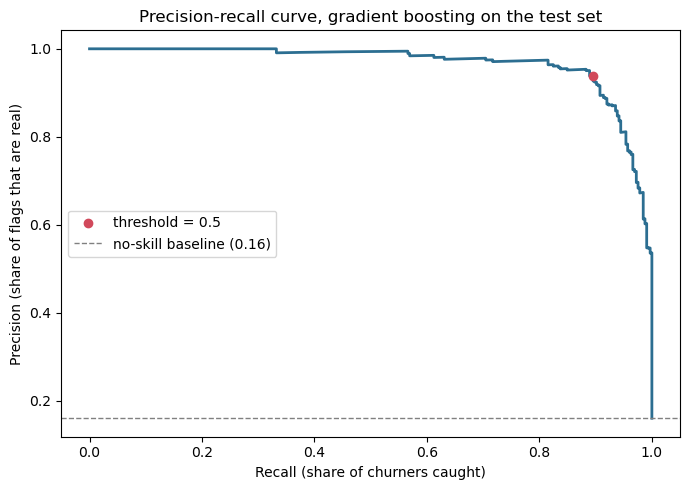

In [10]:
# Precision-recall curve with the 0.5 operating point marked.
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="#2c6e91", lw=2)
ax.scatter([recall_score(y_test, pred_05)], [precision_score(y_test, pred_05)],
           color="#d1495b", zorder=5, label="threshold = 0.5")
ax.axhline(y_test.mean(), color="grey", ls="--", lw=1,
           label=f"no-skill baseline ({y_test.mean():.2f})")
ax.set_xlabel("Recall (share of churners caught)")
ax.set_ylabel("Precision (share of flags that are real)")
ax.set_title("Precision-recall curve, gradient boosting on the test set")
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "nb03_precision_recall.png", dpi=120)
plt.show()


**Inference.** Because the model separates the classes so cleanly, the
precision-recall trade-off is unusually flat. Moving the threshold from 0.5 to 0.8
lifts precision from 93.9 to 95.3 percent while recall only slips from 89.5 to 86.5
percent. In a typical churn problem this curve is much steeper and the threshold is a
hard call. Here there is little to trade.

At the default 0.5 threshold, of 325 real churners the model catches 291 and misses 34,
while raising just 19 false alarms among 1,701 retained customers. In plain terms, for
every 100 customers this model puts on the call list, roughly 94 are genuinely at risk.

**Business reading.**  Precision is already high enough that it stops being the limiting factor. Set the threshold based on how many customers the retention team can actually call each week.


## 8. Score the whole customer book for reporting

The dashboard and the retention team need a risk score for every customer, not just the
test set. Scoring the full book with the model trained on 80 percent of it would give
the training customers optimistic, in-sample scores. To avoid that, each customer is
scored out-of-fold: `cross_val_predict` holds each customer out while the model that
scores them is trained on the others. No customer is scored by a model that saw them.

The probabilities are bucketed into four risk bands for reporting.


In [11]:
oof_proba = cross_val_predict(
    best_model, X, y, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

bands = pd.cut(oof_proba, [-0.001, 0.2, 0.5, 0.8, 1.001],
               labels=["Low", "Medium", "High", "Very High"])

scored = pd.DataFrame({
    "CLIENTNUM": df["CLIENTNUM"],
    "Churn": y,
    "churn_probability": oof_proba.round(4),
    "risk_band": bands,
})

band_summary = (scored.groupby("risk_band", observed=True)
    .agg(customers=("Churn", "size"), actual_churn_rate=("Churn", "mean"))
    .assign(pct_of_book=lambda d: (d["customers"] / len(scored) * 100).round(1),
            actual_churn_rate=lambda d: (d["actual_churn_rate"] * 100).round(1)))
print("Out-of-fold risk bands, with the churn rate actually observed in each:")
print(band_summary.to_string())
print()

high_bands = scored["risk_band"].isin(["High", "Very High"])
print("Customers in High + Very High bands:", int(high_bands.sum()),
      f"({round(high_bands.mean() * 100, 1)} percent of the book)")
print("Share of ALL churners sitting in those two bands:",
      round(scored.loc[high_bands, "Churn"].sum() / scored["Churn"].sum() * 100, 1),
      "percent")


Out-of-fold risk bands, with the churn rate actually observed in each:
           customers  actual_churn_rate  pct_of_book
risk_band                                           
Low             8385                1.1         82.8
Medium           106               39.6          1.0
High             114               47.4          1.1
Very High       1522               94.3         15.0

Customers in High + Very High bands: 1636 (16.2 percent of the book)
Share of ALL churners sitting in those two bands: 91.5 percent


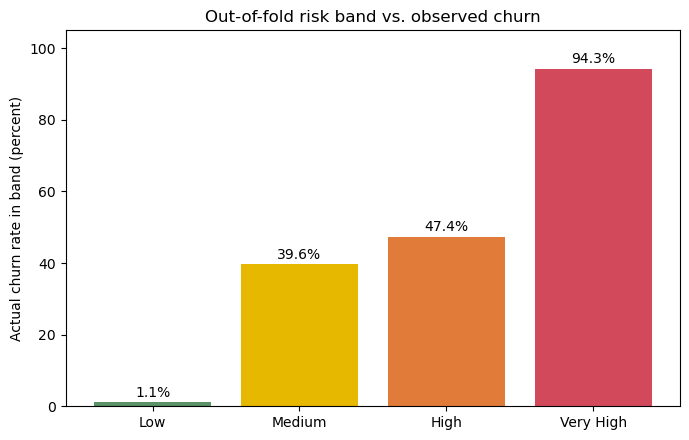

In [12]:
# Chart: actual churn rate by risk band.
order = ["Low", "Medium", "High", "Very High"]
rates = [band_summary.loc[b, "actual_churn_rate"] for b in order]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(order, rates, color=["#5a9367", "#e6b800", "#e07b39", "#d1495b"])
for i, v in enumerate(rates):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center")
ax.set_ylabel("Actual churn rate in band (percent)")
ax.set_title("Out-of-fold risk band vs. observed churn")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "nb03_risk_bands.png", dpi=120)
plt.show()


In [13]:
# Save the scored book for the dashboard, and the fitted model for reuse.
import joblib

SCORED_PATH = BASE / "data" / "processed" / "churn_scored.csv"
scored.to_csv(SCORED_PATH, index=False)

MODEL_DIR = BASE / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "churn_hgb.joblib"
joblib.dump(best_model, MODEL_PATH)

# Verify the scored file reloads cleanly.
check = pd.read_csv(SCORED_PATH)
assert check.shape == scored.shape, "Scored file did not round-trip. Investigate the save."
print("Saved scored book :", SCORED_PATH, check.shape)
print("Saved model       :", MODEL_PATH)


Saved scored book : D:\credit_card_churn_analysis\data\processed\churn_scored.csv (10127, 4)
Saved model       : D:\credit_card_churn_analysis\outputs\models\churn_hgb.joblib


**Inference.** The scored book is the most useful operational output of the whole
project. It sorts the customers cleanly:

- The **Low** band holds 82.8 percent of customers and churns at just 1.1 percent. This
  is the "leave alone" group, and it is most of the book.
- The **Very High** band holds 15.0 percent of customers and churns at 94.3 percent.
- The **High and Very High** bands together, 1,636 customers or 16.2 percent of the
  book, contain 91.5 percent of everyone who churned.

The model concentrates almost all the churn risk into about one sixth of the customers, and clears the other five sixths off the retention team's desk. This concentration is what makes the model useful. The PR-AUC number matters less.

The two middle bands (Medium at 106 customers, High at 114) are thin, so the churn rates
shown for them are noisier than the Low and Very High figures and should be read as
indicative, not precise.


## 9. Business recommendations

These follow only from what the analysis above supports, and each names its own limit.

**1. Work the risk-banded list, not the whole book.** 91.5 percent of churners sit in the top two risk bands, which are 16.2 percent of customers. The retention team should work the Very High band (1,522 customers, 94.3 percent observed churn) first. That band behaves more like a leaving list than an at risk list. The intervention needs to be a genuine save offer. A light nudge will not work here. Caveat: because the model may be reading
signal recorded at the same time as the exit, treat this initially as a win-back and last-chance list and confirm with a holdout that outreach actually changes outcomes.

**2. Monitor transaction frequency as the leading indicator.** `Total_Trans_Ct` and its Q4-to-Q1 change carry the model. The operational rule worth building is to route a customer to retention when their rolling transaction count falls toward half of their prior-period count, which is exactly what `sharp_activity_decline` encodes. This is where that flag earns its place, as the executable monitoring trigger the retention team can run, separate from the model itself. Honest limit: this snapshot cannot prove the drop comes before the decision to leave, so this trigger must be validated on live, timestamped data before it is trusted as genuine early warning.

**3. Do not segment retention by demographics.** Age, income, education, marital status, and the missing-record flag all rank at zero in the model. Effort spent building retention segments around who customers are is effort taken away from monitoring what customers do. That is where all the signal is.

**4. Treat relationship depth as a lever to test, not a proven cause.**
`Total_Relationship_Count` is the strongest non-transaction feature, and customers with fewer products churn more. Deepening the product relationship is a plausible structural lever, but this data is correlational, so it should be framed as a hypothesis to check with a controlled experiment. It is not a settled cause yet.

**5. Run every retention campaign as a controlled experiment.** The model tells you who
is at risk. It does not tell you that calling them helps. Only a randomised holdout,
some at-risk customers contacted and a comparable group not, can measure whether the
programme actually saves customers or just spends money on people who were staying
anyway.


## 10. Limitations and scope

Carried forward from Notebook 02 and extended for the model.

1. **Snapshot, not a forecast.** The behavioural columns are measured over the same
   window in which churn was recorded, with no timestamps, so the model identifies the
   signature of an at-risk account rather than forecasting churn in advance. This is the
   single most important caveat and it governs how every recommendation above is worded.
2. **The scores are unusually high because the dataset is unusually clean.** A PR-AUC of
   0.967 reflects a compact teaching dataset that separates easily. It is not a promise
   of how this approach would score on a real bank's messier production data.
3. **Feature choice was informed by full-data EDA in Notebook 01**, so the reported test
   scores are mildly optimistic. This is a disclosed portfolio compromise. It is stated here on purpose, instead of being left for someone to discover.
   
5. **The engineered flags are redundant to the tree**, as section 6 confirmed. They are
   retained for the linear baseline and for business execution. The gradient boosting model does not need them.
6. **Class imbalance is handled with balanced class weights**, and the model is judged on
   PR-AUC, recall, and precision, never on accuracy.
7. **The two middle risk bands are small**, so their observed churn rates are noisier
   than the Low and Very High bands.
8. **On real data the model would need a retraining cadence** and monitoring for drift.
   A model trained on one snapshot will decay as customer behaviour shifts.


## 11. Summary and handoff

**Model selected**
- Histogram gradient boosting. Test PR-AUC 0.967, ROC-AUC 0.992. At the 0.5 threshold,
  recall 0.895 and precision 0.939.

**What drives it**
- `Total_Trans_Ct` and `Total_Trans_Amt` carry almost the entire model. Demographics and
  the engineered flags rank near zero(under 0.0002).

**Operational output**
- `data/processed/churn_scored.csv`: every customer with an out-of-fold churn probability
  and a risk band. 91.5 percent of churners fall in the top two bands, which are 16.2
  percent of the book.
- `outputs/models/churn_hgb.joblib`: the fitted model, for re-scoring new customers.
- `outputs/charts/`: permutation importance, precision-recall curve, and risk-band charts
  for the README and the dashboard.

**For the README**
- Lead with the concentration result (91.5 percent of churn in 16 percent of customers). That is the number a business acts on, more than the PR-AUC figure.
- State the snapshot caveat plainly next to any performance figure.

**For a Power BI dashboard**
- `churn_scored.csv` is the fact table: one row per customer, joined back to the cleaned
  file on `CLIENTNUM` for the behavioural and demographic detail. Risk band is the
  primary slicer.
